# Modeling

## Анализ сайта "СберАвтоподписка"

Цель ноутбука -> обучить модель машинного обучения, которая предсказывает вероятность совершения пользователем целевого действия на сайте.

На предыдущих этапах были:

- изучены исходные данные
- сформирована целевая переменная `target`
- созданы дополнительные признаки
- подготовлен итоговый датасет для моделирования

На этом этапе будут выполнены:

- загрузка подготовленного датасета
- разделение данных на train/test
- обучение baseline-модели
- обучение основной модели
- оценка качества по ROC-AUC
- построение ROC-кривой
- анализ важности признаков
- сохранение обученного pipeline


## Импорты

In [1]:
# Библиотека для работы с предупреждениями
import warnings

# Библиотеки для работы с данными
import json
import pickle

import numpy as np
import pandas as pd

# Библиотеки для визуализации
import matplotlib.pyplot as plt
import seaborn as sns

# Разделение данных
from sklearn.model_selection import train_test_split

# Pipeline и трансформеры
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Обработка признаков
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Модели
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Метрики
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# Настройки отображения
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

## Импорт модулей проекта

In [2]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd().parent
REPOSITORY_DIR = PROJECT_DIR.parents[3]

if str(REPOSITORY_DIR) not in sys.path:
    sys.path.append(str(REPOSITORY_DIR))

from sessions_tasks.classical_ml.session02.sber_auto_subscription.src.config import (
    PROCESSED_DATASET_PATH,
    MODEL_PATH,
    METRICS_PATH,
    PREDICTIONS_PATH,
    TARGET_COLUMN,
)

## Загружаем подготовленный датасет

In [3]:
dataset = pd.read_csv(PROCESSED_DATASET_PATH)

print(f"Размер датасета: {dataset.shape}")
dataset.head()

Размер датасета: (1860042, 24)


,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,target,visit_month,visit_day,visit_weekday,visit_hour,is_weekend,is_organic_traffic,is_paid_traffic,is_social_traffic,is_first_visit,visit_number_clipped
0,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,0,11,24,2,14,0,0,1,0,1,1
1,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,0,11,14,6,8,1,0,1,0,1,1
2,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,0,12,28,1,2,0,0,1,0,1,1
3,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,29,5,5,1,0,1,0,1,1
4,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,0,5,29,5,5,1,0,1,0,0,2


После исправления датасет содержит только признаки, доступные на момент начала визита.

Таблица `ga_hits` больше не используется для формирования признаков модели.
Она используется только для формирования целевой переменной `target`.

Размер датасета после исключения признаков с риском утечки данных -> `1 860 042` строки и `24` столбца.

In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 24 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   visit_number              int64 
 1   utm_source                object
 2   utm_medium                object
 3   utm_campaign              object
 4   utm_adcontent             object
 5   utm_keyword               object
 6   device_category           object
 7   device_os                 object
 8   device_brand              object
 9   device_screen_resolution  object
 10  device_browser            object
 11  geo_country               object
 12  geo_city                  object
 13  target                    int64 
 14  visit_month               int64 
 15  visit_day                 int64 
 16  visit_weekday             int64 
 17  visit_hour                int64 
 18  is_weekend                int64 
 19  is_organic_traffic        int64 
 20  is_paid_traffic           int64 
 21  is_socia

In [5]:
dataset[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2)

target
0    96.62
1     3.38
Name: proportion, dtype: float64

Данные имеют выраженный дисбаланс классов, доля визитов с целевым действием составляет около 3.4%.
Поэтому основной метрикой качества будет ROC-AUC, а не accuracy.

## Разделяем признаки и target

In [6]:
X = dataset.drop(columns=[TARGET_COLUMN])
y = dataset[TARGET_COLUMN]

print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")

Размер X: (1860042, 23)
Размер y: (1860042,)


## Определяем числовые и категориальные признаки

In [7]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print(f"Количество числовых признаков: {len(numeric_features)}")
print(f"Количество категориальных признаков: {len(categorical_features)}")

print("\nЧисловые признаки:")
display(numeric_features)

print("\nКатегориальные признаки:")
display(categorical_features)

Количество числовых признаков: 11
Количество категориальных признаков: 12

Числовые признаки:


['visit_number',
 'visit_month',
 'visit_day',
 'visit_weekday',
 'visit_hour',
 'is_weekend',
 'is_organic_traffic',
 'is_paid_traffic',
 'is_social_traffic',
 'is_first_visit',
 'visit_number_clipped']


Категориальные признаки:


['utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_screen_resolution',
 'device_browser',
 'geo_country',
 'geo_city']

In [8]:
numeric_features

['visit_number',
 'visit_month',
 'visit_day',
 'visit_weekday',
 'visit_hour',
 'is_weekend',
 'is_organic_traffic',
 'is_paid_traffic',
 'is_social_traffic',
 'is_first_visit',
 'visit_number_clipped']

In [9]:
categorical_features

['utm_source',
 'utm_medium',
 'utm_campaign',
 'utm_adcontent',
 'utm_keyword',
 'device_category',
 'device_os',
 'device_brand',
 'device_screen_resolution',
 'device_browser',
 'geo_country',
 'geo_city']

## Финальная постановка задачи после проверки на утечку данных

В первой версии проекта в модель были включены признаки, рассчитанные по событиям внутри всей сессии:

- количество событий
- количество уникальных страниц
- количество уникальных действий
- бинарные признаки поведения пользователя внутри визита

После анализа было выявлено, что такие признаки могут приводить к утечке данных.

Причина заключается в том, что целевая переменная `target` формируется на основе `ga_hits.event_action`.
Если признаки также рассчитываются по всей таблице `ga_hits` в рамках той же сессии,
то модель может получить информацию о событиях, произошедших после целевого действия.

В исправленной версии проекта `ga_hits` используется только для формирования целевой переменной.

Финальная модель обучается только на признаках, доступных на момент начала визита:

- рекламные признаки -> `utm_source`, `utm_medium`, `utm_campaign`, `utm_keyword`, `utm_adcontent`
- признаки устройства -> `device_category`, `device_os`, `device_brand`, `device_screen_resolution`, `device_browser`
- географические признаки -> `geo_country`, `geo_city`
- временные признаки -> месяц, день, день недели, час визита, признак выходного дня
- признаки повторности визита -> `visit_number`, `is_first_visit`, `visit_number_clipped`

Такой подход дает более честную оценку качества модели, потому что модель больше не использует поведение пользователя из будущего.

In [10]:
leakage_risk_features = {
    "hit_count",
    "max_hit_number",
    "unique_page_count",
    "unique_event_action_count",
    "unique_event_category_count",
    "has_view_card",
    "has_search",
    "has_pagination",
    "has_quiz",
    "has_subscription_interest",
    "has_phone_interaction",
    "has_form_interaction",
}

leakage_features_in_dataset = leakage_risk_features.intersection(dataset.columns)
leakage_features_in_X = leakage_risk_features.intersection(X.columns)

print("Признаки с риском утечки в финальном датасете:")
print(leakage_features_in_dataset)

print("\nПризнаки с риском утечки в обучающей матрице X:")
print(leakage_features_in_X)

assert not leakage_features_in_dataset, "В датасете остались признаки с риском утечки данных"
assert not leakage_features_in_X, "В X остались признаки с риском утечки данных"

Признаки с риском утечки в финальном датасете:
set()

Признаки с риском утечки в обучающей матрице X:
set()


Проверка показала, что признаки с риском утечки данных отсутствуют как в финальном датасете, так и в обучающей матрице `X`.

Это означает, что модель обучается только на признаках визита и не использует агрегированное поведение пользователя внутри полной сессии.

## Делим данные на train/test

In [11]:
# Для дисбаланса используем stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train target rate: {y_train.mean():.4%}")
print(f"y_test target rate: {y_test.mean():.4%}")

X_train: (1488033, 23)
X_test: (372009, 23)
y_train target rate: 3.3818%
y_test target rate: 3.3816%


## Создаем препроцессинг

In [12]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", min_frequency=100)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Для числовых признаков используется заполнение пропусков медианой и масштабирование.

Для категориальных признаков пропуски заполняются значением `unknown`,
после чего применяется OneHotEncoder.
Для ограничения размерности используется параметр `min_frequency=100`, который объединяет редкие категории.

## Baseline-модель

Baseline нужен для сравнения. Он покажет самый частый класс.

In [13]:
baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)
baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_roc_auc = roc_auc_score(y_test, baseline_proba)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline ROC-AUC: {baseline_roc_auc:.4f}")

Baseline accuracy: 0.9662
Baseline ROC-AUC: 0.5000


## Основная модель -> LogisticRegression

In [14]:
logreg_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

logreg_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## Оценка LogisticRegression

In [15]:
logreg_pred = logreg_model.predict(X_test)
logreg_proba = logreg_model.predict_proba(X_test)[:, 1]

logreg_accuracy = accuracy_score(y_test, logreg_pred)
logreg_roc_auc = roc_auc_score(y_test, logreg_proba)

print(f"LogisticRegression accuracy: {logreg_accuracy:.4f}")
print(f"LogisticRegression ROC-AUC: {logreg_roc_auc:.4f}")

LogisticRegression accuracy: 0.5456
LogisticRegression ROC-AUC: 0.6687


In [16]:
print(classification_report(y_test, logreg_pred))

              precision    recall  f1-score   support

           0       0.98      0.54      0.70    359429
           1       0.05      0.69      0.09     12580

    accuracy                           0.55    372009
   macro avg       0.51      0.61      0.39    372009
weighted avg       0.95      0.55      0.68    372009



После исключения признаков с риском утечки данных ROC-AUC модели снизился с первоначального значения около `0.927` до `0.6687`.

Такое снижение ожидаемо, так как модель больше не использует агрегированные признаки поведения внутри всей сессии и
не получает информацию о действиях, которые могли произойти после целевого события.

При этом ROC-AUC остается выше baseline `0.5000` и выше ориентира задачи `0.65`.
Поэтому исправленная модель дает более честный, но все еще полезный результат.

## Матрица ошибок

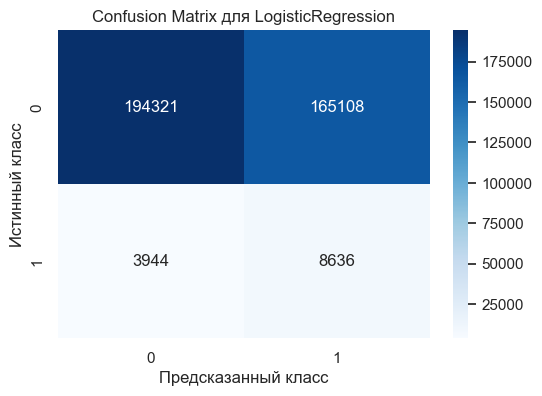

In [17]:
cm = confusion_matrix(y_test, logreg_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
)
plt.title("Confusion Matrix для LogisticRegression")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.show()

##  ROC-кривая

ROC-кривая показывает способность модели разделять визиты с целевым действием и без него при разных порогах классификации.
Чем выше ROC-AUC, тем лучше модель ранжирует пользователей по вероятности конверсии.

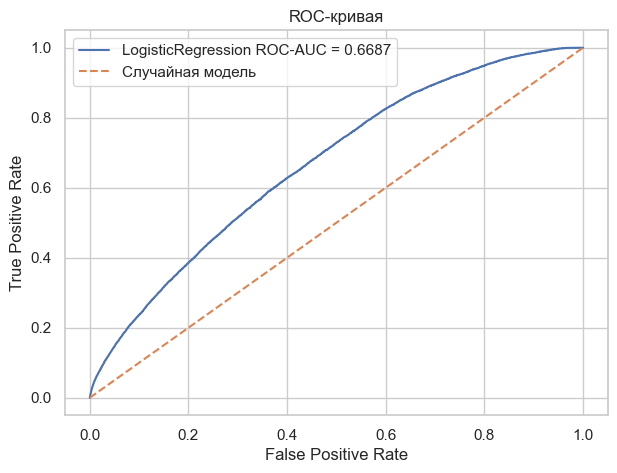

In [18]:
fpr, tpr, thresholds = roc_curve(y_test, logreg_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"LogisticRegression ROC-AUC = {logreg_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Случайная модель")
plt.title("ROC-кривая")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Дополнительная модель -> RandomForestClassifier

Ограничим сложность данной модели, чтобы сократить время обучения.

In [19]:
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=12,
                min_samples_leaf=50,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [20]:
# Метрики RandomForestClassifier
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_proba)

print(f"RandomForest accuracy: {rf_accuracy:.4f}")
print(f"RandomForest ROC-AUC: {rf_roc_auc:.4f}")

RandomForest accuracy: 0.5076
RandomForest ROC-AUC: 0.6682


`RandomForestClassifier` показал ROC-AUC, близкий к `LogisticRegression`, но немного ниже.

С учетом близкого качества, большей скорости обучения и лучшей интерпретируемости в качестве итоговой модели оставлена `LogisticRegression`.

## Сравнение моделей

In [21]:
metrics_df = pd.DataFrame(
    [
        {
            "model": "DummyClassifier",
            "accuracy": baseline_accuracy,
            "roc_auc": baseline_roc_auc,
        },
        {
            "model": "LogisticRegression",
            "accuracy": logreg_accuracy,
            "roc_auc": logreg_roc_auc,
        },
        {
            "model": "RandomForestClassifier",
            "accuracy": rf_accuracy,
            "roc_auc": rf_roc_auc,
        },
    ]
)

metrics_df

,model,accuracy,roc_auc
0,DummyClassifier,0.966184,0.500000
1,LogisticRegression,0.545570,0.668714
2,RandomForestClassifier,0.507552,0.668199


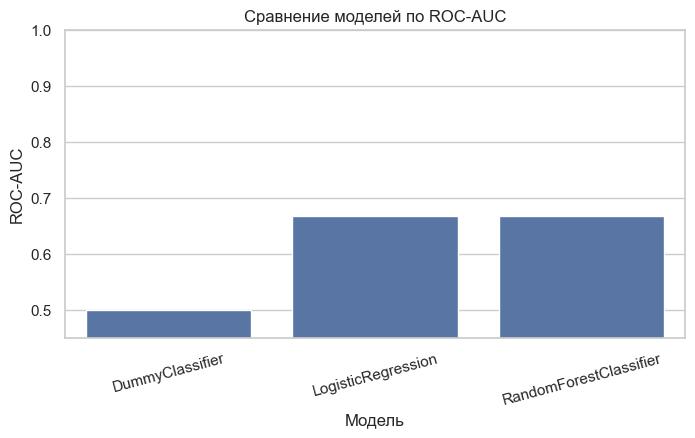

In [22]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=metrics_df,
    x="model",
    y="roc_auc",
)
plt.title("Сравнение моделей по ROC-AUC")
plt.xlabel("Модель")
plt.ylabel("ROC-AUC")
plt.ylim(0.45, 1.0)
plt.xticks(rotation=15)
plt.show()

## Выбор лучшей модели

In [23]:
best_model_name = metrics_df.sort_values("roc_auc", ascending=False).iloc[0]["model"]

if best_model_name == "RandomForestClassifier":
    best_model = rf_model
    best_pred = rf_pred
    best_proba = rf_proba
    best_roc_auc = rf_roc_auc
    best_accuracy = rf_accuracy
else:
    best_model = logreg_model
    best_pred = logreg_pred
    best_proba = logreg_proba
    best_roc_auc = logreg_roc_auc
    best_accuracy = logreg_accuracy

print(f"Лучшая модель: {best_model_name}")
print(f"ROC-AUC лучшей модели: {best_roc_auc:.4f}")

Лучшая модель: LogisticRegression
ROC-AUC лучшей модели: 0.6687


Лучшей моделью по ROC-AUC стала `LogisticRegression`.

Так как логистическая регрессия является линейной моделью,
для нее можно интерпретировать коэффициенты признаков и
оценить направление влияния признаков на вероятность целевого действия.

## Интерпретация признаков для LogisticRegression

Коэффициенты логистической регрессии позволяют оценить, какие признаки сильнее связаны с вероятностью целевого действия.

В исправленной версии модели среди признаков больше нет агрегатов по событиям внутри полной сессии.
Поэтому интерпретация относится только к признакам,
доступным на момент начала визита -> источникам трафика, устройству, географии, времени и номеру визита.

In [24]:
feature_names = logreg_model.named_steps["preprocessor"].get_feature_names_out()
coefficients = logreg_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame(
    {
        "feature": feature_names,
        "coefficient": coefficients,
        "abs_coefficient": np.abs(coefficients),
    }
).sort_values("abs_coefficient", ascending=False)

coef_df.head(30)

,feature,coefficient,abs_coefficient
664,cat__device_screen_resolution_2000x2000,-4.912665,4.912665
1119,cat__geo_city_Prineville,-3.046038,3.046038
1052,cat__geo_city_Lulea,-2.959461,2.959461
826,cat__device_screen_resolution_800x600,-2.887029,2.887029
931,cat__geo_city_Ashburn,-2.670669,2.670669
977,cat__geo_city_Forest City,-2.664973,2.664973
49,cat__utm_source_fgymSoTvjKPEgaIJqsiH,-2.481065,2.481065
313,cat__utm_adcontent_PkybGvWbaqORmxjNunqZ,2.479444,2.479444
360,cat__utm_adcontent_xhoenQgDQsgfEPYNPwKO,2.436874,2.436874
343,cat__utm_adcontent_qalfRbxdosSpdWRPPVpn,-2.410732,2.410732


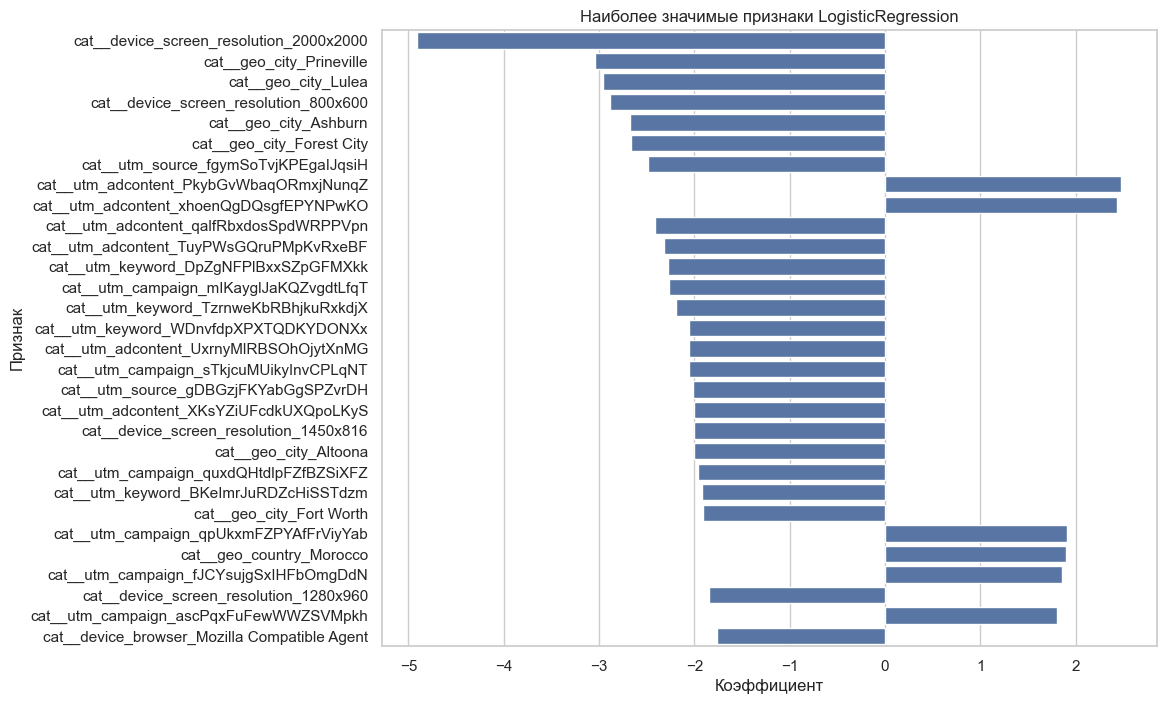

In [25]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=coef_df.head(30),
    x="coefficient",
    y="feature",
)
plt.title("Наиболее значимые признаки LogisticRegression")
plt.xlabel("Коэффициент")
plt.ylabel("Признак")
plt.show()

## Вывод по моделированию

На этапе моделирования был использован исправленный датасет размером `1 860 042` строки и `24` столбца.

Целевая переменная имеет выраженный дисбаланс классов:

- около `3.38%` визитов содержат целевое действие
- около `96.62%` визитов не приводят к целевому действию

Для корректной оценки качества данные были разделены на обучающую и тестовую выборки с сохранением пропорции классов через `stratify=y`.

В качестве baseline-модели был использован `DummyClassifier`, который всегда предсказывает наиболее частый класс.

Baseline показал:

- `accuracy` -> `0.9662`
- `ROC-AUC` -> `0.5000`

Высокая accuracy baseline объясняется сильным дисбалансом классов.
ROC-AUC `0.5000` показывает, что такая модель не умеет ранжировать визиты по вероятности целевого действия.

После исключения признаков с риском утечки данных были обучены две модели.

`LogisticRegression` показала:

- `accuracy` -> `0.5456`
- `ROC-AUC` -> `0.6687`

`RandomForestClassifier` показал:

- `accuracy` -> `0.5076`
- `ROC-AUC` -> `0.6682`

Лучшей моделью по ROC-AUC стала `LogisticRegression`.

Важно, что после исправления ROC-AUC снизился по сравнению с первой версией модели, где значение было около `0.927`.
Это ожидаемый результат, так как первая версия использовала признаки, рассчитанные по событиям всей сессии, что создавало риск утечки данных.

В исправленной версии модель обучается только на признаках, доступных на момент начала визита:

- источники трафика
- рекламные метки
- устройство
- браузер
- география
- дата и время визита
- номер визита пользователя

Полученный ROC-AUC `0.6687` выше baseline `0.5000` и выше ориентира задачи `0.65`.

Таким образом, исправленная модель показывает более скромный, но более честный результат.
Она может использоваться для оценки вероятности целевого действия по данным визита без использования информации о будущих действиях пользователя.

## Сохраняем предсказания

In [26]:
predictions_df = X_test.copy()
predictions_df["target"] = y_test.values
predictions_df["prediction"] = best_pred
predictions_df["probability"] = best_proba

predictions_df.to_csv(PREDICTIONS_PATH, index=False)

print(f"Предсказания сохранены: {PREDICTIONS_PATH}")
print(f"Размер файла с предсказаниями: {predictions_df.shape}")

Предсказания сохранены: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/outputs/predictions.csv
Размер файла с предсказаниями: (372009, 26)


## Сохраняем метрики

In [27]:
metrics = {
    "dataset": {
        "rows": int(dataset.shape[0]),
        "columns": int(dataset.shape[1]),
        "target_rate": round(float(y.mean()), 4),
        "leakage_risk_features_used": False,
    },
    "baseline": {
        "accuracy": round(float(baseline_accuracy), 4),
        "roc_auc": round(float(baseline_roc_auc), 4),
    },
    "logistic_regression": {
        "accuracy": round(float(logreg_accuracy), 4),
        "roc_auc": round(float(logreg_roc_auc), 4),
    },
    "random_forest": {
        "accuracy": round(float(rf_accuracy), 4),
        "roc_auc": round(float(rf_roc_auc), 4),
    },
    "best_model": {
        "name": best_model_name,
        "accuracy": round(float(best_accuracy), 4),
        "roc_auc": round(float(best_roc_auc), 4),
    },
}

with open(METRICS_PATH, "w", encoding="utf-8") as file:
    json.dump(metrics, file, ensure_ascii=False, indent=4)

print(f"Метрики сохранены: {METRICS_PATH}")

Метрики сохранены: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/outputs/metrics.json


## Сохраняем модель

In [28]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(MODEL_PATH, "wb") as file:
    pickle.dump(best_model, file)

print(f"Модель сохранена: {MODEL_PATH}")

Модель сохранена: /Users/pontigor/python_test/mephi_homework_tasks/sessions_tasks/classical_ml/session02/sber_auto_subscription/models/model.pkl


## Итог третьего этапа

На этапе моделирования была решена задача бинарной классификации,
модель предсказывает вероятность совершения пользователем целевого действия на сайте.

После проверки проекта была обнаружена методологическая проблема первой версии модели,
часть признаков рассчитывалась по событиям внутри всей сессии.

Так как целевая переменная также формируется на основе событий `ga_hits.event_action`,
такие признаки могли содержать информацию о действиях, произошедших после целевого события.

Для устранения риска утечки данных из финального датасета были исключены признаки:

- агрегаты по количеству событий
- количество уникальных страниц
- количество уникальных действий
- бинарные поведенческие признаки внутри сессии

В финальной версии `ga_hits` используется только для формирования целевой переменной `target`.

Модель обучается на признаках, доступных на момент начала визита:

- `utm_*`
- `device_*`
- `geo_*`
- временные признаки визита
- номер визита пользователя

В качестве baseline использовалась модель `DummyClassifier`.
Она показала ROC-AUC `0.5000`, что соответствует случайному ранжированию.

Итоговая модель `LogisticRegression` показала ROC-AUC `0.6687`.
Это значение выше baseline и выше ориентира задачи `0.65`.

Результат ниже, чем в первой версии модели, но является более честным,
так как модель больше не использует информацию о будущих действиях пользователя.

Лучшая модель сохранена в файл `models/model.pkl`,
метрики качества в `outputs/metrics.json`,
предсказания на тестовой выборке в `outputs/predictions.csv`.